# Credit Score Multi Class Classification

In [89]:
import pandas as pd

train_data = pd.read_csv('../dataset/train.csv')
test_data = pd.read_csv('../dataset/test.csv')

print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)

train_data.head()

C:\Users\adiln\AppData\Local\Temp\ipykernel_19640\3792723488.py:3: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('../dataset/train.csv')


Train Data Shape: (100000, 28)
Test Data Shape: (50000, 27)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [90]:
train_data.dtypes

ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                

In [91]:
train_data['Credit_Score'].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

Data Preprocessing and Feature Engineering steps

The ID, Customer_ID, Month, Name, and SSN features can be dropped as they are not relevant for the classification task. The target variable is 'Credit_Score', which is a categorical variable with three classes: 'Poor', 'Standard', and 'Good'. We will encode this target variable using label encoding.

In [92]:
from sklearn.preprocessing import LabelEncoder
labelEncoder = LabelEncoder()

train_data = train_data.drop(['ID', 'Customer_ID', 'Month', 'Name', 'SSN'], axis=1)

In [93]:
# Looping through each column and printing missing values and data types
print("Missing values:\n", train_data.isnull().sum())

Missing values:
 Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64


In [94]:
# Age
# Converting Age to numeric and checking for outliers
train_data['Age'] = pd.to_numeric(train_data['Age'], errors='coerce')

# Printing number of rows with Age > 110
print("Number of rows with Age > 110:", (train_data['Age'] > 110).sum())
print("Number of rows with Age < 18:", (train_data['Age'] < 18).sum())

# Removing rows with Age > 110 (clearly invalid) and cap Age < 18 to 18 (might be data entry errors). This balances data quality with retention.
train_data = train_data[train_data['Age'] <= 110]
train_data.loc[train_data['Age'] < 18, 'Age'] = 18 

Number of rows with Age > 110: 1803
Number of rows with Age < 18: 6319


In [95]:
# Occupation column has "_______" as a category
# Count of rows with "_______" in Occupation column
print("Number of rows with '_______' in Occupation column:", (train_data['Occupation'] == '_______').sum())

most_common = train_data[train_data['Occupation'] != '_______']['Occupation'].mode()[0]
train_data['Occupation'] = train_data['Occupation'].replace('_______', most_common)

Number of rows with '_______' in Occupation column: 6609


In [96]:
# Annual_Income 
print("Unique values in Annual_Income column:", train_data['Annual_Income'].unique())

# I see "_" is at the end of many values in Annual_Income column. I will remove the "_" and convert the column to numeric.
train_data['Annual_Income'] = train_data['Annual_Income'].str.replace('_', '', regex=False)
train_data['Annual_Income'] = pd.to_numeric(train_data['Annual_Income'], errors='coerce')

# Monthly_Inhand_Salary
print("Unique values in Monthly_Inhand_Salary column:", train_data['Monthly_Inhand_Salary'].unique())

print("Number of rows with NaN in Monthly_Inhand_Salary column:", train_data['Monthly_Inhand_Salary'].isnull().sum())

# Converting Monthly_Inhand_Salary to numeric and filling NaN values with median
train_data['Monthly_Inhand_Salary'] = train_data['Monthly_Inhand_Salary'].fillna(train_data['Monthly_Inhand_Salary'].median())


Unique values in Annual_Income column: ['19114.12' '34847.84' '34847.84_' ... '20002.88' '39628.99' '39628.99_']
Unique values in Monthly_Inhand_Salary column: [1824.84333333           nan 3037.98666667 ... 3097.00833333 1929.90666667
 3359.41583333]
Number of rows with NaN in Monthly_Inhand_Salary column: 14011


In [97]:
# Num_of_Loan
# Number of rows with _ at the end of Num_of_Loan column
print("Number of rows with '_' at the end of Num_of_Loan column:", train_data['Num_of_Loan'].astype(str).str.endswith('_').sum()) #4479

# Removing "_" from Num_of_Loan column and converting it to numeric
train_data['Num_of_Loan'] = train_data['Num_of_Loan'].astype(str).str.replace('_', '', regex=False)
train_data['Num_of_Loan'] = pd.to_numeric(train_data['Num_of_Loan'], errors='coerce')

Number of rows with '_' at the end of Num_of_Loan column: 4479


In [98]:
# Type_of_Loan
print("Unique values in Type_of_Loan column:", train_data['Type_of_Loan'].unique())

# Handling Type_of_Loan - create binary features for each loan type
# Filling NaN values
train_data['Type_of_Loan'] = train_data['Type_of_Loan'].fillna('Not Specified')

# Extract all unique loan types
all_loan_types = set()
for loans in train_data['Type_of_Loan'].dropna():
    if isinstance(loans, str):
        # Split by comma and 'and', clean up
        loan_list = loans.replace(' and ', ', ').split(', ')
        all_loan_types.update([loan.strip() for loan in loan_list])

print(f"Unique loan types: {sorted(all_loan_types)}")

# Create binary columns for each loan type
for loan_type in all_loan_types:
    if loan_type and loan_type != '':
        column_name = f'Has_{loan_type.replace(" ", "_").replace("-", "_")}'
        train_data[column_name] = train_data['Type_of_Loan'].str.contains(
            loan_type, case=False, na=False
        ).astype(int)

# Optional: Create a count feature
train_data['Num_Loan_Types'] = train_data['Type_of_Loan'].apply(
    lambda x: len(x.split(',')) if isinstance(x, str) and x != 'Not Specified' else 0
)

# Drop the original column
train_data = train_data.drop('Type_of_Loan', axis=1)

Unique values in Type_of_Loan column: ['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'
 'Credit-Builder Loan' 'Auto Loan, Auto Loan, and Not Specified' ...
 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan'
 'Payday Loan, Student Loan, Mortgage Loan, and Not Specified'
 'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan']
Unique loan types: ['Auto Loan', 'Auto Loan,', 'Credit-Builder Loan', 'Credit-Builder Loan,', 'Debt Consolidation Loan', 'Debt Consolidation Loan,', 'Home Equity Loan', 'Home Equity Loan,', 'Mortgage Loan', 'Mortgage Loan,', 'Not Specified', 'Not Specified,', 'Payday Loan', 'Payday Loan,', 'Personal Loan', 'Personal Loan,', 'Student Loan', 'Student Loan,']


In [99]:
# Num_of_Delayed_Payment
print("Unique values in Num_of_Delayed_Payment column:", train_data['Num_of_Delayed_Payment'].unique())

# Number of rows with _ at the end of Num_of_Delayed_Payment column
print("Number of rows with '_' at the end of Num_of_Delayed_Payment column:", train_data['Num_of_Delayed_Payment'].astype(str).str.endswith('_').sum())

# Removing "_" from Num_of_Delayed_Payment column and converting it to numeric
train_data['Num_of_Delayed_Payment'] = train_data['Num_of_Delayed_Payment'].astype(str).str.replace('_', '', regex=False)
train_data['Num_of_Delayed_Payment'] = pd.to_numeric(train_data['Num_of_Delayed_Payment'], errors='coerce')

# Filling missing values in Num_of_Delayed_Payment with median
train_data['Num_of_Delayed_Payment'] = train_data['Num_of_Delayed_Payment'].fillna(train_data['Num_of_Delayed_Payment'].median())

Unique values in Num_of_Delayed_Payment column: ['7' nan '4' '8_' '6' '1' '-1' '3_' '0' '8' '5' '3' '9' '12' '15' '17'
 '10' '2' '14' '11' '20' '22' '13' '13_' '14_' '16' '12_' '18' '19' '23'
 '24' '21' '3318' '3083' '22_' '1338' '26' '11_' '3104' '21_' '25' '10_'
 '183_' '1106' '834' '19_' '24_' '17_' '23_' '2672' '20_' '4_' '2008' '-3'
 '538' '6_' '1_' '16_' '27' '3478' '2420' '707' '708' '26_' '18_' '3815'
 '9_' '28' '5_' '-2' '1867' '2250' '1463' '25_' '7_' '2882' '1941' '2655'
 '15_' '2628' '132' '3069' '306' '0_' '3539' '1823' '4128' '1946' '827'
 '2297' '2566' '904' '182' '929' '3568' '2503' '1552' '2812' '1697' '3764'
 '851' '3905' '923' '88' '1668' '3253' '808' '2689' '3858' '642' '3457'
 '1402' '1732' '3154' '3037' '2204' '3103' '2_' '1063' '2056' '1282'
 '1841' '211' '793' '3484' '411' '3491' '2072' '3050' '1049' '2162' '3402'
 '2753' '27_' '1718' '1014' '3260' '3855' '84' '2311' '3251' '1832' '4069'
 '3010' '733' '4241' '166' '2461' '1749' '3200' '663_' '2185' '4161'
 '3009

In [100]:
# Changed_Credit_Limit
print("Unique values in Changed_Credit_Limit column:", train_data['Changed_Credit_Limit'].unique())

# Number of rows with _ at the end of Changed_Credit_Limit column
print("Number of rows with '_' at the end of Changed_Credit_Limit column:", train_data['Changed_Credit_Limit'].astype(str).str.endswith('_').sum())

# Removing "_" from Changed_Credit_Limit column and converting it to numeric
train_data['Changed_Credit_Limit'] = train_data['Changed_Credit_Limit'].astype(str).str.replace('_', '', regex=False)
train_data['Changed_Credit_Limit'] = pd.to_numeric(train_data['Changed_Credit_Limit'], errors='coerce')

# Filling missing values in Changed_Credit_Limit with median
train_data['Changed_Credit_Limit'] = train_data['Changed_Credit_Limit'].fillna(train_data['Changed_Credit_Limit'].median())

Unique values in Changed_Credit_Limit column: ['11.27' '_' '6.27' ... '25.16' '21.17' '3.6199999999999988']
Number of rows with '_' at the end of Changed_Credit_Limit column: 1949


In [ ]:
# Num_Credit_Inquiries
print("Unique values in Num_Credit_Inquiries column:", train_data['Num_Credit_Inquiries'].unique())

# Num_Credit_Inquiries - convert to numeric and handle outliers
train_data['Num_Credit_Inquiries'] = pd.to_numeric(train_data['Num_Credit_Inquiries'], errors='coerce')

# Checking distribution
print("Num_Credit_Inquiries statistics:")
print(train_data['Num_Credit_Inquiries'].describe())

# Capping outliers at a reasonable maximum (e.g., 15-20)
# Values > 100 are likely data entry errors
train_data.loc[train_data['Num_Credit_Inquiries'] > 20, 'Num_Credit_Inquiries'] = 20

# Filling missing values with median
train_data['Num_Credit_Inquiries'] = train_data['Num_Credit_Inquiries'].fillna(
    train_data['Num_Credit_Inquiries'].median()
)


Unique values in Num_Credit_Inquiries column: [4.000e+00 2.000e+00 3.000e+00 ... 2.448e+03 1.361e+03 7.400e+01]
Num_Credit_Inquiries statistics:
count    91413.000000
mean        27.822126
std        193.386125
min          0.000000
25%          3.000000
50%          6.000000
75%          9.000000
max       2597.000000
Name: Num_Credit_Inquiries, dtype: float64


In [ ]:
# Num_Bank_Accounts
print("Num_Bank_Accounts statistics:")
print(train_data['Num_Bank_Accounts'].describe())
print("Unique values count:", train_data['Num_Bank_Accounts'].nunique())

# Converting to numeric and handle any issues
train_data['Num_Bank_Accounts'] = pd.to_numeric(train_data['Num_Bank_Accounts'], errors='coerce')
train_data['Num_Bank_Accounts'] = train_data['Num_Bank_Accounts'].fillna(train_data['Num_Bank_Accounts'].median())

Num_Bank_Accounts statistics:
count    93258.000000
mean        17.039750
std        117.088494
min         -1.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64
Unique values count: 889


In [ ]:
# Num_Credit_Card
print("Num_Credit_Card statistics:")
print(train_data['Num_Credit_Card'].describe())
print("Values > 20:", (train_data['Num_Credit_Card'] > 20).sum())

# Converting to numeric and cap outliers (realistic range 0-15)
train_data['Num_Credit_Card'] = pd.to_numeric(train_data['Num_Credit_Card'], errors='coerce')
train_data.loc[train_data['Num_Credit_Card'] > 15, 'Num_Credit_Card'] = 15
train_data['Num_Credit_Card'] = train_data['Num_Credit_Card'].fillna(train_data['Num_Credit_Card'].median())

Num_Credit_Card statistics:
count    93258.000000
mean        22.463606
std        129.003737
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max       1499.000000
Name: Num_Credit_Card, dtype: float64
Values > 20: 2109


In [ ]:
# Interest_Rate
print("Interest_Rate statistics:")
print(train_data['Interest_Rate'].describe())
print("Negative values:", (train_data['Interest_Rate'] < 0).sum())

# Converting to numeric and handle negative values
train_data['Interest_Rate'] = pd.to_numeric(train_data['Interest_Rate'], errors='coerce')
# Negative interest rates don't make sense, replace with median
train_data.loc[train_data['Interest_Rate'] < 0, 'Interest_Rate'] = train_data['Interest_Rate'].median()
train_data['Interest_Rate'] = train_data['Interest_Rate'].fillna(train_data['Interest_Rate'].median())

Interest_Rate statistics:
count    93258.000000
mean        72.714201
std        467.223039
min          1.000000
25%          8.000000
50%         14.000000
75%         20.000000
max       5797.000000
Name: Interest_Rate, dtype: float64
Negative values: 0


In [ ]:
# Delay_from_due_date
print("Delay_from_due_date statistics:")
print(train_data['Delay_from_due_date'].describe())

# Converting to numeric (negative values mean paid early, which is fine)
train_data['Delay_from_due_date'] = pd.to_numeric(train_data['Delay_from_due_date'], errors='coerce')
train_data['Delay_from_due_date'] = train_data['Delay_from_due_date'].fillna(train_data['Delay_from_due_date'].median())

Delay_from_due_date statistics:
count    93258.000000
mean        21.075758
std         14.859114
min         -5.000000
25%         10.000000
50%         18.000000
75%         28.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64


In [ ]:
# Credit_Mix
print("Credit_Mix unique values:", train_data['Credit_Mix'].unique())
print("Credit_Mix value counts:")
print(train_data['Credit_Mix'].value_counts())

# Replacing '_' with 'Unknown' and filling NaN
train_data['Credit_Mix'] = train_data['Credit_Mix'].replace('_', 'Unknown')
train_data['Credit_Mix'] = train_data['Credit_Mix'].fillna('Unknown')

Credit_Mix unique values: ['_' 'Good' 'Standard' 'Bad']
Credit_Mix value counts:
Credit_Mix
Standard    34074
Good        22662
_           18827
Bad         17695
Name: count, dtype: int64


In [ ]:
# Outstanding_Debt
print("Outstanding_Debt statistics:")
print(train_data['Outstanding_Debt'].describe())

# Removing underscores and converting to numeric
train_data['Outstanding_Debt'] = train_data['Outstanding_Debt'].astype(str).str.replace('_', '', regex=False)
train_data['Outstanding_Debt'] = pd.to_numeric(train_data['Outstanding_Debt'], errors='coerce')
train_data['Outstanding_Debt'] = train_data['Outstanding_Debt'].fillna(train_data['Outstanding_Debt'].median())

Outstanding_Debt statistics:
count       93258
unique      13110
top       1109.03
freq           21
Name: Outstanding_Debt, dtype: object


In [ ]:
# Credit_Utilization_Ratio
print("Credit_Utilization_Ratio statistics:")
print(train_data['Credit_Utilization_Ratio'].describe())

# Converting to numeric
train_data['Credit_Utilization_Ratio'] = pd.to_numeric(train_data['Credit_Utilization_Ratio'], errors='coerce')
train_data['Credit_Utilization_Ratio'] = train_data['Credit_Utilization_Ratio'].fillna(train_data['Credit_Utilization_Ratio'].median())

Credit_Utilization_Ratio statistics:
count    93258.000000
mean        32.289269
std          5.118897
min         20.000000
25%         28.052683
50%         32.313880
75%         36.505310
max         50.000000
Name: Credit_Utilization_Ratio, dtype: float64


In [ ]:
# Credit_History_Age
print("Credit_History_Age sample values:", train_data['Credit_History_Age'].head(20))
print("Missing values:", train_data['Credit_History_Age'].isnull().sum())

# Parsing Credit_History_Age (e.g., "22 Years and 1 Months") to total months
def parse_credit_history_age(series):
    if series.dtype == 'object':
        years = series.astype(str).str.extract(r'(\d+)\s*Years?', expand=False).astype(float)
        months = series.astype(str).str.extract(r'(\d+)\s*Months?', expand=False).astype(float)

        total_months = years.fillna(0) * 12 + months.fillna(0)
        return total_months
    return series

train_data['Credit_History_Age'] = parse_credit_history_age(train_data['Credit_History_Age'])
train_data['Credit_History_Age'] = train_data['Credit_History_Age'].fillna(train_data['Credit_History_Age'].median())

print("Credit_History_Age after processing:", train_data['Credit_History_Age'].describe())

Credit_History_Age sample values: 0      22 Years and 1 Months
1                        NaN
2      22 Years and 3 Months
3      22 Years and 4 Months
4      22 Years and 5 Months
5      22 Years and 6 Months
6      22 Years and 7 Months
7                        NaN
9      26 Years and 8 Months
10     26 Years and 9 Months
11    26 Years and 10 Months
12    26 Years and 11 Months
13     27 Years and 0 Months
14     27 Years and 1 Months
15     27 Years and 2 Months
16     17 Years and 9 Months
17    17 Years and 10 Months
18    17 Years and 11 Months
19                       NaN
20     18 Years and 1 Months
Name: Credit_History_Age, dtype: object
Missing values: 8415
Credit_History_Age after processing: count    93258.000000
mean       201.320037
std        114.305814
min          0.000000
25%        114.000000
50%        208.000000
75%        292.000000
max        404.000000
Name: Credit_History_Age, dtype: float64


In [ ]:
# Payment_of_Min_Amount
print("Payment_of_Min_Amount unique values:", train_data['Payment_of_Min_Amount'].unique())
print("Payment_of_Min_Amount value counts:")
print(train_data['Payment_of_Min_Amount'].value_counts())

# Replacing 'NM' with 'Unknown' and handle missing values
train_data['Payment_of_Min_Amount'] = train_data['Payment_of_Min_Amount'].replace('NM', 'Unknown')
train_data['Payment_of_Min_Amount'] = train_data['Payment_of_Min_Amount'].fillna('Unknown')

Payment_of_Min_Amount unique values: ['No' 'NM' 'Yes']
Payment_of_Min_Amount value counts:
Payment_of_Min_Amount
Yes    48811
No     33216
NM     11231
Name: count, dtype: int64


In [ ]:
# Total_EMI_per_month
print("Total_EMI_per_month statistics:")
print(train_data['Total_EMI_per_month'].describe())

# Converting to numeric
train_data['Total_EMI_per_month'] = pd.to_numeric(train_data['Total_EMI_per_month'], errors='coerce')
train_data['Total_EMI_per_month'] = train_data['Total_EMI_per_month'].fillna(train_data['Total_EMI_per_month'].median())

Total_EMI_per_month statistics:
count    93258.000000
mean      1390.066487
std       8252.914280
min          0.000000
25%         30.338204
50%         69.268455
75%        161.224249
max      82331.000000
Name: Total_EMI_per_month, dtype: float64


In [ ]:
# Amount_invested_monthly
print("Amount_invested_monthly sample values:", train_data['Amount_invested_monthly'].head(20))

# Checking for special patterns like __10000__
print("Values with underscores:", train_data['Amount_invested_monthly'].astype(str).str.contains('__', na=False).sum())

# Removing underscores and convert to numeric
train_data['Amount_invested_monthly'] = train_data['Amount_invested_monthly'].astype(str).str.replace('_', '', regex=False)
train_data['Amount_invested_monthly'] = pd.to_numeric(train_data['Amount_invested_monthly'], errors='coerce')
train_data['Amount_invested_monthly'] = train_data['Amount_invested_monthly'].fillna(train_data['Amount_invested_monthly'].median())

print("Amount_invested_monthly after processing:", train_data['Amount_invested_monthly'].describe())

Amount_invested_monthly sample values: 0      80.41529543900253
1     118.28022162236736
2        81.699521264648
3      199.4580743910713
4     41.420153086217326
5     62.430172331195294
6      178.3440674122349
7     24.785216509052056
9      40.39123782853101
10     58.51597569589465
11     99.30622796053305
12    130.11542024292334
13    43.477190144355745
14     70.10177420755677
15    218.90434353388733
16      168.413702679309
17    232.86038375993544
18             __10000__
19     825.2162699393922
20     430.9475278803298
Name: Amount_invested_monthly, dtype: object
Values with underscores: 3987
Amount_invested_monthly after processing: count    93258.000000
mean       612.179590
std       1993.125588
min          0.000000
25%         77.079124
50%        136.156810
75%        255.379266
max      10000.000000
Name: Amount_invested_monthly, dtype: float64


In [ ]:
# Payment_Behaviour
print("Payment_Behaviour unique values:", train_data['Payment_Behaviour'].unique())
print("Payment_Behaviour value counts:")
print(train_data['Payment_Behaviour'].value_counts())

# Replacing garbage values like !@9#%8 with Unknown
# Valid patterns should contain words like 'spent', 'value', 'payments'
def clean_payment_behaviour(value):
    if pd.isna(value):
        return 'Unknown'
    if not any(word in str(value) for word in ['spent', 'value', 'payments', 'Low', 'High', 'Small', 'Large', 'Medium']):
        return 'Unknown'
    return value

train_data['Payment_Behaviour'] = train_data['Payment_Behaviour'].apply(clean_payment_behaviour)

Payment_Behaviour unique values: ['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' '!@9#%8'
 'High_spent_Large_value_payments']
Payment_Behaviour value counts:
Payment_Behaviour
Low_spent_Small_value_payments      23786
High_spent_Medium_value_payments    16372
Low_spent_Medium_value_payments     12944
High_spent_Large_value_payments     12777
High_spent_Small_value_payments     10580
Low_spent_Large_value_payments       9712
!@9#%8                               7087
Name: count, dtype: int64


In [ ]:
# Monthly_Balance
print("Monthly_Balance statistics:")
print(train_data['Monthly_Balance'].describe())

# Removing underscores and convert to numeric
train_data['Monthly_Balance'] = train_data['Monthly_Balance'].astype(str).str.replace('_', '', regex=False)
train_data['Monthly_Balance'] = pd.to_numeric(train_data['Monthly_Balance'], errors='coerce')
train_data['Monthly_Balance'] = train_data['Monthly_Balance'].fillna(train_data['Monthly_Balance'].median())

Monthly_Balance statistics:
count                                92135
unique                               92127
top       __-333333333333333333333333333__
freq                                     9
Name: Monthly_Balance, dtype: object


## Summary after preprocessing
Checking data types and missing values after all preprocessing steps.

In [ ]:


print("Data shape after preprocessing:", train_data.shape)
print("\nMissing values after processing:\n", train_data.isnull().sum())
print("\nData types:\n", train_data.dtypes)
print("\nCategorical columns:")
print(train_data.select_dtypes(include=['object']).columns.tolist())

Data shape after preprocessing: (93258, 41)

Missing values after processing:
 Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age              0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly         0
Payment_Behaviour               0
Monthly_Balance                 0
Credit_Score                    0
Has_Credit_Builder_Loan,        0
Has_Student_Loan,               0
Has_Payday_Loan                 0
Has_Debt_Consolidation_Loan     0
Has_Student_Loan                0
Has

In [ ]:
# Label Encoding for categorical columns
from sklearn.preprocessing import LabelEncoder

categorical_columns = train_data.select_dtypes(include=['object']).columns.tolist()
# Removing target variable from categorical columns if present
if 'Credit_Score' in categorical_columns:
    categorical_columns.remove('Credit_Score')

print(f"Encoding {len(categorical_columns)} categorical columns: {categorical_columns}")

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values")

print("\nAll columns are now numeric!")

Encoding 4 categorical columns: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
  Occupation: 15 unique values
  Credit_Mix: 4 unique values
  Payment_of_Min_Amount: 3 unique values
  Payment_Behaviour: 7 unique values

All columns are now numeric!


Splitting the data into training and validation sets.

In [117]:
train_data.dtypes

Age                             float64
Occupation                        int64
Annual_Income                   float64
Monthly_Inhand_Salary           float64
Num_Bank_Accounts                 int64
Num_Credit_Card                   int64
Interest_Rate                     int64
Num_of_Loan                       int64
Delay_from_due_date               int64
Num_of_Delayed_Payment          float64
Changed_Credit_Limit            float64
Num_Credit_Inquiries            float64
Credit_Mix                        int64
Outstanding_Debt                float64
Credit_Utilization_Ratio        float64
Credit_History_Age              float64
Payment_of_Min_Amount             int64
Total_EMI_per_month             float64
Amount_invested_monthly         float64
Payment_Behaviour                 int64
Monthly_Balance                 float64
Credit_Score                     object
Has_Credit_Builder_Loan,          int64
Has_Student_Loan,                 int64
Has_Payday_Loan                   int64


In [118]:
from sklearn.model_selection import train_test_split

X = train_data.drop('Credit_Score', axis=1)
y = train_data['Credit_Score']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train Shape:", X_train.shape)
print("X_val Shape:", X_val.shape)
print("y_train Shape:", y_train.shape)
print("y_val Shape:", y_val.shape)

X_train Shape: (74606, 40)
X_val Shape: (18652, 40)
y_train Shape: (74606,)
y_val Shape: (18652,)


In [ ]:
# Scaling features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

print("Scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")

Scaling complete!
X_train_scaled shape: (74606, 40)
X_val_scaled shape: (18652, 40)


# Logistic Regression

In [120]:
# Logistic Regression
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_val_scaled)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score as roc_auc_multiclass

y_val_binarized = label_binarize(y_val, classes=np.unique(y_train))
y_pred_proba = model.predict_proba(X_val_scaled)
roc_auc = roc_auc_multiclass(y_val_binarized, y_pred_proba, average='weighted', multi_class='ovr')

mcc = matthews_corrcoef(y_val, y_pred)

print(f"Logistic Regression Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  ROC AUC:   {roc_auc:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  MCC:       {mcc:.4f}")

Logistic Regression Results:
  Accuracy:  0.6276
  ROC AUC:   0.7567
  Precision: 0.6247
  Recall:    0.6276
  F1 Score:  0.6182
  MCC:       0.3491


# Decision Tree Classifier

In [121]:

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_val_scaled)

accuracy_dt = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt, average='weighted')
recall_dt = recall_score(y_val, y_pred_dt, average='weighted')
f1_dt = f1_score(y_val, y_pred_dt, average='weighted')

y_pred_proba_dt = dt_model.predict_proba(X_val_scaled)
roc_auc_dt = roc_auc_multiclass(y_val_binarized, y_pred_proba_dt, average='weighted', multi_class='ovr')

mcc_dt = matthews_corrcoef(y_val, y_pred_dt)

print(f"Decision Tree Classifier Results:")
print(f"  Accuracy:  {accuracy_dt:.4f}")
print(f"  ROC AUC:   {roc_auc_dt:.4f}")
print(f"  Precision: {precision_dt:.4f}")
print(f"  Recall:    {recall_dt:.4f}")
print(f"  F1 Score:  {f1_dt:.4f}")
print(f"  MCC:       {mcc_dt:.4f}")

Decision Tree Classifier Results:
  Accuracy:  0.6888
  ROC AUC:   0.7338
  Precision: 0.6895
  Recall:    0.6888
  F1 Score:  0.6891
  MCC:       0.4811


# K-Nearest Neighbors Classifier

In [122]:

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_val_scaled)

accuracy_knn = accuracy_score(y_val, y_pred_knn)
precision_knn = precision_score(y_val, y_pred_knn, average='weighted')
recall_knn = recall_score(y_val, y_pred_knn, average='weighted')
f1_knn = f1_score(y_val, y_pred_knn, average='weighted')

y_pred_proba_knn = knn_model.predict_proba(X_val_scaled)
roc_auc_knn = roc_auc_multiclass(y_val_binarized, y_pred_proba_knn, average='weighted', multi_class='ovr')

mcc_knn = matthews_corrcoef(y_val, y_pred_knn)

print(f"K-Nearest Neighbors Classifier Results:")
print(f"  Accuracy:  {accuracy_knn:.4f}")
print(f"  ROC AUC:   {roc_auc_knn:.4f}")
print(f"  Precision: {precision_knn:.4f}")
print(f"  Recall:    {recall_knn:.4f}")
print(f"  F1 Score:  {f1_knn:.4f}")
print(f"  MCC:       {mcc_knn:.4f}")

K-Nearest Neighbors Classifier Results:
  Accuracy:  0.7048
  ROC AUC:   0.8283
  Precision: 0.7045
  Recall:    0.7048
  F1 Score:  0.7046
  MCC:       0.5058


# Naive Bayes Classifier (Gaussian)

In [123]:

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_val_scaled)

accuracy_nb = accuracy_score(y_val, y_pred_nb)
precision_nb = precision_score(y_val, y_pred_nb, average='weighted')
recall_nb = recall_score(y_val, y_pred_nb, average='weighted')
f1_nb = f1_score(y_val, y_pred_nb, average='weighted')

y_pred_proba_nb = nb_model.predict_proba(X_val_scaled)
roc_auc_nb = roc_auc_multiclass(y_val_binarized, y_pred_proba_nb, average='weighted', multi_class='ovr')

mcc_nb = matthews_corrcoef(y_val, y_pred_nb)

print(f"Naive Bayes (Gaussian) Classifier Results:")
print(f"  Accuracy:  {accuracy_nb:.4f}")
print(f"  ROC AUC:   {roc_auc_nb:.4f}")
print(f"  Precision: {precision_nb:.4f}")
print(f"  Recall:    {recall_nb:.4f}")
print(f"  F1 Score:  {f1_nb:.4f}")
print(f"  MCC:       {mcc_nb:.4f}")

Naive Bayes (Gaussian) Classifier Results:
  Accuracy:  0.5068
  ROC AUC:   0.6931
  Precision: 0.5960
  Recall:    0.5068
  F1 Score:  0.4945
  MCC:       0.3259


# Random Forest Classifier

In [132]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=15)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_val_scaled)

accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf, average='weighted')
recall_rf = recall_score(y_val, y_pred_rf, average='weighted')
f1_rf = f1_score(y_val, y_pred_rf, average='weighted')

y_pred_proba_rf = rf_model.predict_proba(X_val_scaled)
roc_auc_rf = roc_auc_multiclass(y_val_binarized, y_pred_proba_rf, average='weighted', multi_class='ovr')

mcc_rf = matthews_corrcoef(y_val, y_pred_rf)

print(f"Random Forest Classifier Results:")
print(f"  Accuracy:  {accuracy_rf:.4f}")
print(f"  ROC AUC:   {roc_auc_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall:    {recall_rf:.4f}")
print(f"  F1 Score:  {f1_rf:.4f}")
print(f"  MCC:       {mcc_rf:.4f}")

Random Forest Classifier Results:
  Accuracy:  0.7551
  ROC AUC:   0.8696
  Precision: 0.7572
  Recall:    0.7551
  F1 Score:  0.7558
  MCC:       0.5918


# XGBoost Classifier

In [126]:
! pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.7/101.7 MB 18.0 MB/s eta 0:00:06
   -- ------------------------------------- 6.0/101.7 MB 15.2 MB/s eta 0:00:07
   --- ------------------------------------ 8.9/101.7 MB 14.0 MB/s eta 0:00:07
   ---- ----------------------------------- 11.0/101.7 MB 13.6 MB/s eta 0:00:07
   ----- ---------------------------------- 13.6/101.7 MB 13.1 MB/s eta 0:00:07
   ------ --------------------------------- 16.5/101.7 MB 12.8 MB/s eta 0:00:07
   ------- -------------------------------- 19.1/101.7 MB 12.8 MB/s eta 0:00:07
   -------- ------------------------------- 20.4/101.7 MB 12.0 MB/s eta 0:00:07
   -------- ------------------------------- 21.5/101.7 MB 11.2 MB/s eta 0:00:08
   --------- ------------------------------ 23.3/101.7 MB 10.9 MB/s eta 0:00:08
   --------- ------------------------------ 25.2/101.7 MB 10.7 MB/s eta 0:00:08
   ---------- ----------------------------- 27.5/101


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [127]:

from xgboost import XGBClassifier

# Encoding target labels to 0, 1, 2 for XGBoost
label_encoder_target = LabelEncoder()
y_train_encoded = label_encoder_target.fit_transform(y_train)
y_val_encoded = label_encoder_target.transform(y_val)

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_scaled, y_train_encoded)
y_pred_xgb_encoded = xgb_model.predict(X_val_scaled)

# Converting predictions back to original labels
y_pred_xgb = label_encoder_target.inverse_transform(y_pred_xgb_encoded)

accuracy_xgb = accuracy_score(y_val, y_pred_xgb)
precision_xgb = precision_score(y_val, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_val, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_val, y_pred_xgb, average='weighted')

y_pred_proba_xgb = xgb_model.predict_proba(X_val_scaled)
roc_auc_xgb = roc_auc_multiclass(y_val_binarized, y_pred_proba_xgb, average='weighted', multi_class='ovr')

mcc_xgb = matthews_corrcoef(y_val, y_pred_xgb)

print(f"XGBoost Classifier Results:")
print(f"  Accuracy:  {accuracy_xgb:.4f}")
print(f"  ROC AUC:   {roc_auc_xgb:.4f}")
print(f"  Precision: {precision_xgb:.4f}")
print(f"  Recall:    {recall_xgb:.4f}")
print(f"  F1 Score:  {f1_xgb:.4f}")
print(f"  MCC:       {mcc_xgb:.4f}")

XGBoost Classifier Results:
  Accuracy:  0.7546
  ROC AUC:   0.8731
  Precision: 0.7554
  Recall:    0.7546
  F1 Score:  0.7549
  MCC:       0.5904


# Model Comparison Summary

In [128]:
# Creating comparison dataframe
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors', 
              'Naive Bayes (Gaussian)', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_dt, accuracy_knn, accuracy_nb, accuracy_rf, accuracy_xgb],
    'ROC AUC': [roc_auc, roc_auc_dt, roc_auc_knn, roc_auc_nb, roc_auc_rf, roc_auc_xgb],
    'Precision': [precision, precision_dt, precision_knn, precision_nb, precision_rf, precision_xgb],
    'Recall': [recall, recall_dt, recall_knn, recall_nb, recall_rf, recall_xgb],
    'F1 Score': [f1, f1_dt, f1_knn, f1_nb, f1_rf, f1_xgb],
    'MCC': [mcc, mcc_dt, mcc_knn, mcc_nb, mcc_rf, mcc_xgb]
})

# Rounding to 4 decimal places
results_df = results_df.round(4)

# Sorting by Accuracy (descending)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("Model Comparison Summary:")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)
print(f"\nBest Model by Accuracy: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Accuracy']:.4f})")

Model Comparison Summary:
                 Model  Accuracy  ROC AUC  Precision  Recall  F1 Score    MCC
         Random Forest    0.7956   0.9010     0.7956  0.7956    0.7955 0.6590
               XGBoost    0.7546   0.8731     0.7554  0.7546    0.7549 0.5904
   K-Nearest Neighbors    0.7048   0.8283     0.7045  0.7048    0.7046 0.5058
         Decision Tree    0.6888   0.7338     0.6895  0.6888    0.6891 0.4811
   Logistic Regression    0.6276   0.7567     0.6247  0.6276    0.6182 0.3491
Naive Bayes (Gaussian)    0.5068   0.6931     0.5960  0.5068    0.4945 0.3259

Best Model by Accuracy: Random Forest (0.7956)


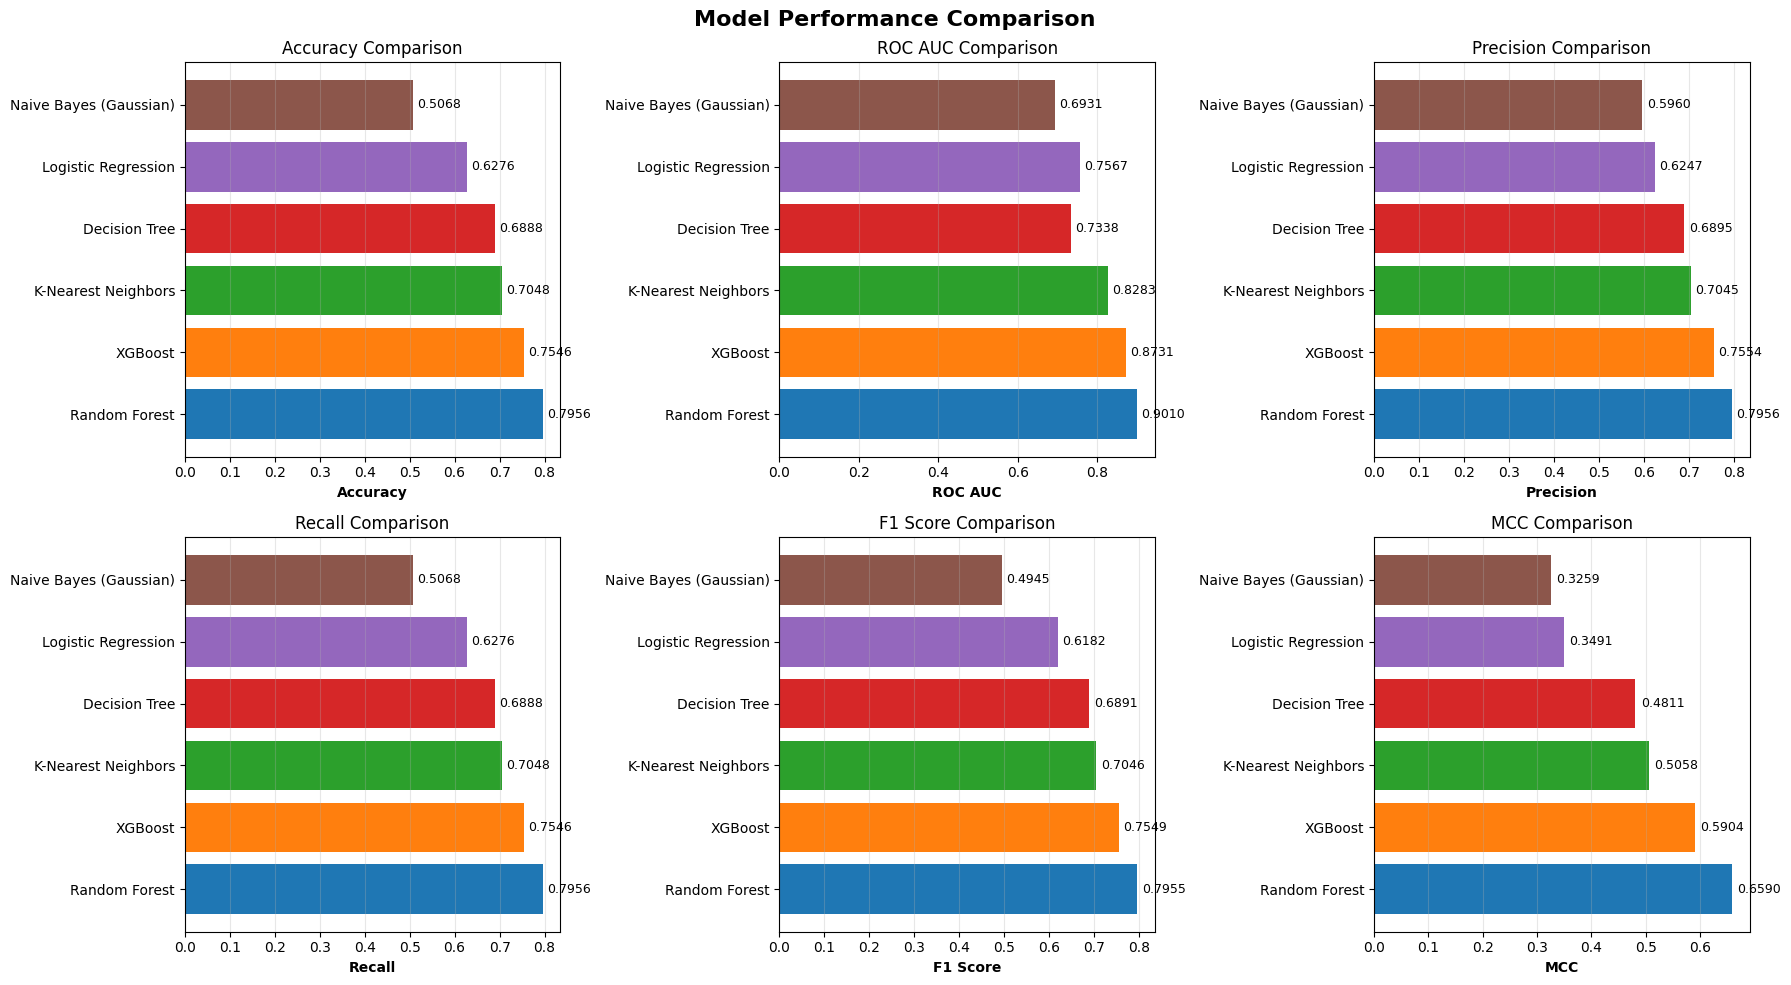

In [129]:
# Visualizing model comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1 Score', 'MCC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (ax, metric) in enumerate(zip(axes.flatten(), metrics)):
    ax.barh(results_df['Model'], results_df[metric], color=colors)
    ax.set_xlabel(metric, fontweight='bold')
    ax.set_title(f'{metric} Comparison')
    ax.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(results_df[metric]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Save Models and Preprocessing Objects
Saving all trained models, scaler, and label encoders for use in the Streamlit app.

In [133]:
import pickle
import os

os.makedirs('../saved_models', exist_ok=True)

models_dict = {
    'logistic_regression': model,
    'decision_tree': dt_model,
    'knn': knn_model,
    'naive_bayes': nb_model,
    'random_forest': rf_model,
    'xgboost': xgb_model
}

for model_name, trained_model in models_dict.items():
    with open(f'../saved_models/{model_name}.pkl', 'wb') as f:
        pickle.dump(trained_model, f)
    print(f"Saved: {model_name}.pkl")

with open('../saved_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved: scaler.pkl")

with open('../saved_models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("Saved: label_encoders.pkl")

with open('../saved_models/target_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder_target, f)
print("Saved: target_encoder.pkl")

with open('../saved_models/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)
print("Saved: feature_names.pkl")

results_df.to_csv('../saved_models/model_results.csv', index=False)
print("Saved: model_results.csv")

print("\n✓ All models and preprocessing objects saved successfully!")

Saved: logistic_regression.pkl
Saved: decision_tree.pkl
Saved: knn.pkl
Saved: naive_bayes.pkl
Saved: random_forest.pkl
Saved: xgboost.pkl
Saved: scaler.pkl
Saved: label_encoders.pkl
Saved: target_encoder.pkl
Saved: feature_names.pkl
Saved: model_results.csv

✓ All models and preprocessing objects saved successfully!
